Figure saved to: energy_profile.png


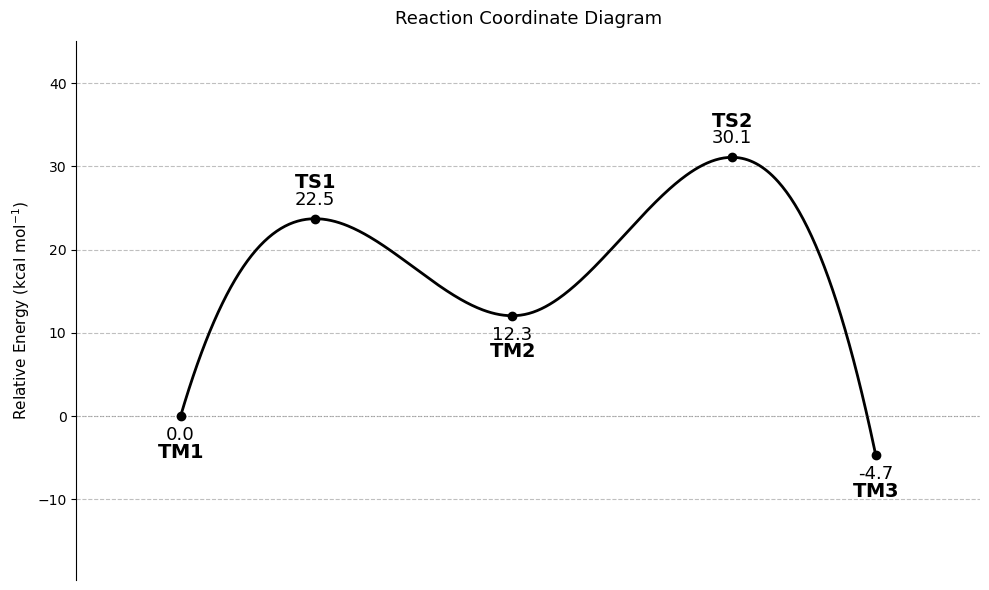

In [1]:
"""
Reaction Coordinate Energy Profile Diagram
-------------------------------------------
Draws a smooth energy profile curve through a series of intermediates/transition states.
Each point has a label (e.g. TM1, TS1) and an energy in kcal/mol.

Customize the `points` list below to change labels and energies.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize_scalar

# ──────────────────────────────────────────────
#  USER INPUT: define your intermediates here
# ──────────────────────────────────────────────
points = [
    {"label": "TM1", "energy":  0.0},   # Starting point
    {"label": "TS1", "energy": 22.5},   # Transition state 1
    {"label": "TM2", "energy": 12.3},   # Intermediate
    {"label": "TS2", "energy": 30.1},   # Transition state 2
    {"label": "TM3", "energy": -4.7},   # Product / final intermediate
]

# ──────────────────────────────────────────────
#  STYLE SETTINGS
# ──────────────────────────────────────────────
FIGURE_SIZE      = (10, 6)
CURVE_COLOR      = "black"
CURVE_LINEWIDTH  = 2.0
POINT_COLOR      = "black"
POINT_SIZE       = 6
LABEL_FONTSIZE   = 14
ENERGY_FONTSIZE  = 13
LABEL_OFFSET_Y   = 2    # vertical offset for the label above/below the point
ENERGY_OFFSET_Y  = 1.2    # vertical offset for the kcal/mol number
X_PADDING        = 0.6    # extra horizontal space on left/right
Y_PADDING        = 5      # extra vertical space on top/bottom
GRID_ALPHA       = 0.5


def build_smooth_curve(x_pts, y_pts, n_interp=500):
    """
    Build a smooth cubic spline through the given control points.
    Returns (x_fine, y_fine) arrays for plotting.
    """
    cs = CubicSpline(x_pts, y_pts, bc_type="not-a-knot")
    x_fine = np.linspace(x_pts[0], x_pts[-1], n_interp)
    y_fine = cs(x_fine)
    return x_fine, y_fine


def label_position(idx, energy, all_energies):
    """
    Decide whether to place the label above or below the point.
    Transition states (local maxima) get labels above;
    intermediates (local minima) get labels below.
    """
    n = len(all_energies)
    is_max = (
        (idx == 0 and energy > all_energies[1]) or
        (idx == n - 1 and energy > all_energies[n - 2]) or
        (0 < idx < n - 1 and energy > all_energies[idx - 1] and energy > all_energies[idx + 1])
    )
    return is_max  # True → above, False → below


def plot_energy_profile(points, save_path=None):
    energies = [p["energy"] for p in points]
    labels   = [p["label"]  for p in points]
    n        = len(points)

    # Evenly spaced x positions
    x_pts = np.arange(n, dtype=float)

    # Build smooth curve
    x_fine, y_fine = build_smooth_curve(x_pts, energies)

    # ── Figure setup ──────────────────────────────
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # ── Draw curve ────────────────────────────────
    ax.plot(x_fine, y_fine, color=CURVE_COLOR, linewidth=CURVE_LINEWIDTH, zorder=2)

    # ── Draw points & labels ──────────────────────
    for i, (label, energy) in enumerate(zip(labels, energies)):
        above = label_position(i, energy, energies)
        
        # Find the true extremum of the spline near this point
        search_margin = 0.4  # search within ±0.4 x-units of the point
        x_lo = max(x_pts[0], i - search_margin)
        x_hi = min(x_pts[-1], i + search_margin)
        
        if above:  # transition state → find maximum (minimize negative)
            result = minimize_scalar(lambda x: -CubicSpline(x_pts, energies)(x),
                                    bounds=(x_lo, x_hi), method="bounded")
        else:       # intermediate → find minimum
            result = minimize_scalar(lambda x:  CubicSpline(x_pts, energies)(x),
                                    bounds=(x_lo, x_hi), method="bounded")
        
        x_dot = result.x
        y_dot = CubicSpline(x_pts, energies)(x_dot)

        ax.plot(x_dot, y_dot, "o", color=POINT_COLOR, markersize=POINT_SIZE, zorder=3)

        sign = 1 if above else -1
        ax.text(x_dot, y_dot + sign * (LABEL_OFFSET_Y + ENERGY_OFFSET_Y),
                f"$\\mathbf{{{label}}}$",
                ha="center", va="bottom" if above else "top",
                fontsize=LABEL_FONTSIZE, color="black")
        ax.text(x_dot, y_dot + sign * ENERGY_OFFSET_Y,
                f"{energy:.1f}",
                ha="center", va="bottom" if above else "top",
                fontsize=ENERGY_FONTSIZE, color="black")

    # ── Axes styling ──────────────────────────────
    y_min, y_max = min(energies), max(energies)
    ax.set_xlim(-X_PADDING, n - 1 + X_PADDING)
    ax.set_ylim(y_min - Y_PADDING * 3, y_max + Y_PADDING * 3)

    # Remove x-axis ticks (not meaningful)
    ax.set_xticks([])

    # Y-axis label
    ax.set_ylabel("Relative Energy (kcal mol$^{-1}$)", fontsize=11)

    # Light horizontal grid for readability
    ax.yaxis.grid(True, linestyle="--", alpha=GRID_ALPHA, color="gray")
    ax.set_axisbelow(True)

    # Remove top/right spines for a clean look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # ── Zero reference line ───────────────────────
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":", alpha=0.5)

    # ── Title ─────────────────────────────────────
    ax.set_title("Reaction Coordinate Diagram", fontsize=13, pad=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    plt.show()


if __name__ == "__main__":
    plot_energy_profile(points, save_path="energy_profile.png")

### Without the Y-axis

Figure saved to: energy_profile.png


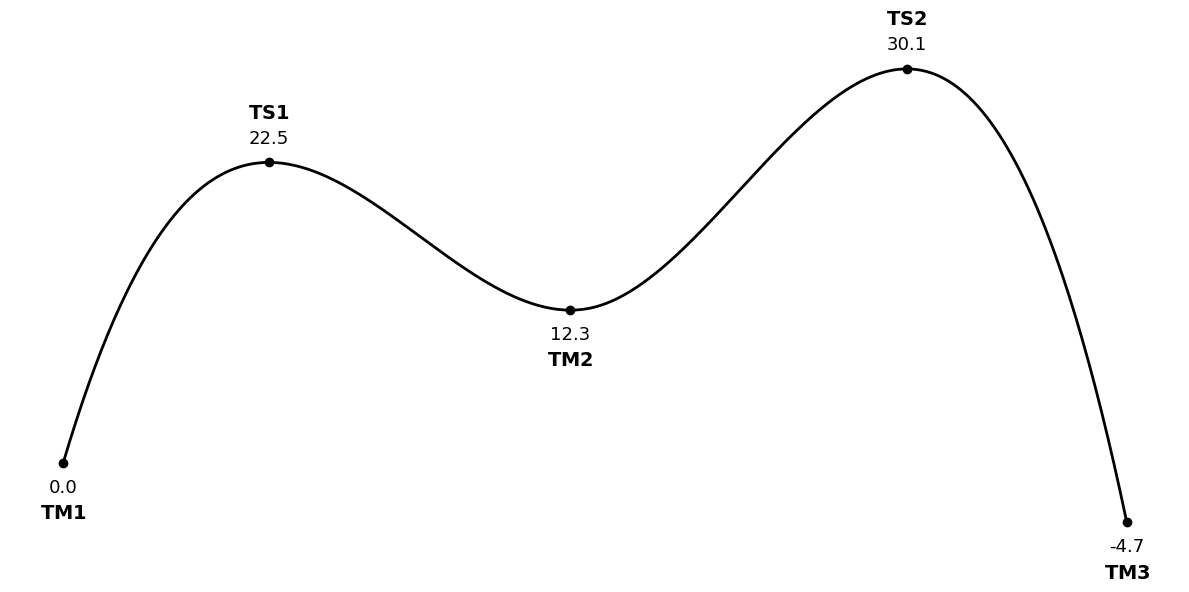

In [21]:
# ──────────────────────────────────────────────
#  USER INPUT: define your intermediates here
# ──────────────────────────────────────────────
points = [
    {"label": "TM1", "energy": 0.0},   # Starting point
    {"label": "TS1", "energy": 22.5},   # Transition state 1
    {"label": "TM2", "energy": 12.3},   # Intermediate
    {"label": "TS2", "energy": 30.1},   # Transition state 2
    {"label": "TM3", "energy": -4.7},   # Product / final intermediate
]

# ──────────────────────────────────────────────
#  STYLE SETTINGS
# ──────────────────────────────────────────────
FIGURE_SIZE      = (12, 6)
CURVE_COLOR      = "black"
CURVE_LINEWIDTH  = 2.0
POINT_COLOR      = "black"
POINT_SIZE       = 6
LABEL_FONTSIZE   = 14
ENERGY_FONTSIZE  = 13
LABEL_OFFSET_Y   = 2    # vertical offset for the label above/below the point
ENERGY_OFFSET_Y  = 1.2    # vertical offset for the kcal/mol number
X_PADDING        = 0.6    # extra horizontal space on left/right
Y_PADDING        = 5      # extra vertical space on top/bottom
GRID_ALPHA       = 0.5


def build_smooth_curve(x_pts, y_pts, n_interp=500):
    """
    Build a smooth cubic spline through the given control points.
    Returns (x_fine, y_fine) arrays for plotting.
    """
    cs = CubicSpline(x_pts, y_pts, bc_type="not-a-knot")
    x_fine = np.linspace(x_pts[0], x_pts[-1], n_interp)
    y_fine = cs(x_fine)
    return x_fine, y_fine


def label_position(idx, energy, all_energies):
    """
    Decide whether to place the label above or below the point.
    Transition states (local maxima) get labels above;
    intermediates (local minima) get labels below.
    """
    n = len(all_energies)
    is_max = (
        (idx == 0 and energy > all_energies[1]) or
        (idx == n - 1 and energy > all_energies[n - 2]) or
        (0 < idx < n - 1 and energy > all_energies[idx - 1] and energy > all_energies[idx + 1])
    )
    return is_max  # True → above, False → below


def plot_energy_profile(points, save_path=None):
    energies = [p["energy"] for p in points]
    labels   = [p["label"]  for p in points]
    n        = len(points)

    # Evenly spaced x positions
    x_pts = np.arange(n, dtype=float)

    # Build smooth curve
    x_fine, y_fine = build_smooth_curve(x_pts, energies)

    # ── Figure setup ──────────────────────────────
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # ── Draw curve ────────────────────────────────
    ax.plot(x_fine, y_fine, color=CURVE_COLOR, linewidth=CURVE_LINEWIDTH, zorder=2)

    # ── Draw points & labels ──────────────────────
    for i, (label, energy) in enumerate(zip(labels, energies)):
        above = label_position(i, energy, energies)
        
        # Find the true extremum of the spline near this point
        search_margin = 0.4  # search within ±0.4 x-units of the point
        x_lo = max(x_pts[0], i - search_margin)
        x_hi = min(x_pts[-1], i + search_margin)
        
        if above:  # transition state → find maximum (minimize negative)
            result = minimize_scalar(lambda x: -CubicSpline(x_pts, energies)(x),
                                    bounds=(x_lo, x_hi), method="bounded")
        else:       # intermediate → find minimum
            result = minimize_scalar(lambda x:  CubicSpline(x_pts, energies)(x),
                                    bounds=(x_lo, x_hi), method="bounded")
        
        x_dot = result.x
        y_dot = CubicSpline(x_pts, energies)(x_dot)

        ax.plot(x_dot, y_dot, "o", color=POINT_COLOR, markersize=POINT_SIZE, zorder=3)

        sign = 1 if above else -1
        ax.text(x_dot, y_dot + sign * (LABEL_OFFSET_Y + ENERGY_OFFSET_Y),
                f"$\\mathbf{{{label}}}$",
                ha="center", va="bottom" if above else "top",
                fontsize=LABEL_FONTSIZE, color="black")
        ax.text(x_dot, y_dot + sign * ENERGY_OFFSET_Y,
                f"{energy:.1f}",
                ha="center", va="bottom" if above else "top",
                fontsize=ENERGY_FONTSIZE, color="black")

    # ── Axes styling ──────────────────────────────
    # y_min, y_max = min(energies), max(energies)
    # ax.set_xlim(-X_PADDING, n - 1 + X_PADDING)
    # ax.set_ylim(y_min - Y_PADDING * 3, y_max + Y_PADDING * 3)

    # Remove x-axis ticks (not meaningful)
    ax.set_xticks([])

    # Remove top/right spines for a clean look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.set_ylabel("")        # or just delete the set_ylabel line
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)

    # ── Zero reference line ───────────────────────
    # ax.axhline(0, color="gray", linewidth=0.8, linestyle=":", alpha=0.5)

    # ── Title ─────────────────────────────────────
    # ax.set_title("Reaction Coordinate Diagram", fontsize=13, pad=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    plt.show()


if __name__ == "__main__":
    plot_energy_profile(points, save_path="energy_profile.png")

### Pathway with dimers included

Figure saved to: energy_profile.png


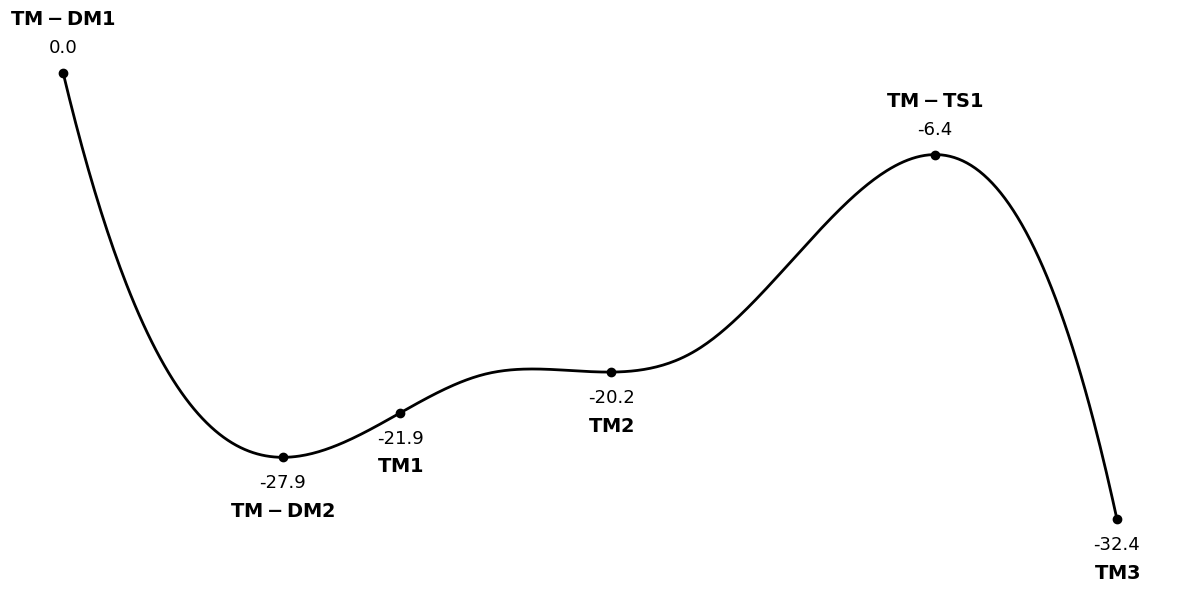

In [2]:
# ──────────────────────────────────────────────
#  USER INPUT: define your intermediates here
# ──────────────────────────────────────────────
points = [
    {"label": "TM-DM1", "energy": 0.0},   # Starting point
    {"label": "TM-DM2", "energy": -27.9}, 
    {"label": "TM1", "energy": -21.9},   
    {"label": "TM2", "energy": -20.2},   
    {"label": "TM-TS1", "energy": -6.4},   
    {"label": "TM3", "energy": -32.4},    
]

# ──────────────────────────────────────────────
#  STYLE SETTINGS
# ──────────────────────────────────────────────
FIGURE_SIZE      = (12, 6)
CURVE_COLOR      = "black"
CURVE_LINEWIDTH  = 2.0
POINT_COLOR      = "black"
POINT_SIZE       = 6
LABEL_FONTSIZE   = 14
ENERGY_FONTSIZE  = 13
LABEL_OFFSET_Y   = 2    # vertical offset for the label above/below the point
ENERGY_OFFSET_Y  = 1.2    # vertical offset for the kcal/mol number
X_PADDING        = 0.6    # extra horizontal space on left/right
Y_PADDING        = 5      # extra vertical space on top/bottom
GRID_ALPHA       = 0.5


def build_smooth_curve(x_pts, y_pts, n_interp=500):
    """
    Build a smooth cubic spline through the given control points.
    Returns (x_fine, y_fine) arrays for plotting.
    """
    cs = CubicSpline(x_pts, y_pts, bc_type="not-a-knot")
    x_fine = np.linspace(x_pts[0], x_pts[-1], n_interp)
    y_fine = cs(x_fine)
    return x_fine, y_fine


def label_position(idx, energy, all_energies):
    """
    Decide whether to place the label above or below the point.
    Transition states (local maxima) get labels above;
    intermediates (local minima) get labels below.
    """
    n = len(all_energies)
    is_max = (
        (idx == 0 and energy > all_energies[1]) or
        (idx == n - 1 and energy > all_energies[n - 2]) or
        (0 < idx < n - 1 and energy > all_energies[idx - 1] and energy > all_energies[idx + 1])
    )
    return is_max  # True → above, False → below


def plot_energy_profile(points, save_path=None):
    energies = [p["energy"] for p in points]
    labels   = [p["label"]  for p in points]
    n        = len(points)

    # Evenly spaced x positions
    x_pts = np.arange(n, dtype=float)

    # Build smooth curve
    x_fine, y_fine = build_smooth_curve(x_pts, energies)

    # ── Figure setup ──────────────────────────────
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # ── Draw curve ────────────────────────────────
    ax.plot(x_fine, y_fine, color=CURVE_COLOR, linewidth=CURVE_LINEWIDTH, zorder=2)

    # ── Draw points & labels ──────────────────────
    for i, (label, energy) in enumerate(zip(labels, energies)):
        above = label_position(i, energy, energies)
        
        # Find the true extremum of the spline near this point
        search_margin = 0.4  # search within ±0.4 x-units of the point
        x_lo = max(x_pts[0], i - search_margin)
        x_hi = min(x_pts[-1], i + search_margin)
        
        if above:  # transition state → find maximum (minimize negative)
            result = minimize_scalar(lambda x: -CubicSpline(x_pts, energies)(x),
                                    bounds=(x_lo, x_hi), method="bounded")
        else:       # intermediate → find minimum
            result = minimize_scalar(lambda x:  CubicSpline(x_pts, energies)(x),
                                    bounds=(x_lo, x_hi), method="bounded")
        
        x_dot = result.x
        y_dot = CubicSpline(x_pts, energies)(x_dot)

        ax.plot(x_dot, y_dot, "o", color=POINT_COLOR, markersize=POINT_SIZE, zorder=3)

        sign = 1 if above else -1
        ax.text(x_dot, y_dot + sign * (LABEL_OFFSET_Y + ENERGY_OFFSET_Y),
                f"$\\mathbf{{{label}}}$",
                ha="center", va="bottom" if above else "top",
                fontsize=LABEL_FONTSIZE, color="black")
        ax.text(x_dot, y_dot + sign * ENERGY_OFFSET_Y,
                f"{energy:.1f}",
                ha="center", va="bottom" if above else "top",
                fontsize=ENERGY_FONTSIZE, color="black")

    # ── Axes styling ──────────────────────────────
    # y_min, y_max = min(energies), max(energies)
    # ax.set_xlim(-X_PADDING, n - 1 + X_PADDING)
    # ax.set_ylim(y_min - Y_PADDING * 3, y_max + Y_PADDING * 3)

    # Remove x-axis ticks (not meaningful)
    ax.set_xticks([])

    # Remove top/right spines for a clean look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.set_ylabel("")        # or just delete the set_ylabel line
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)

    # ── Zero reference line ───────────────────────
    # ax.axhline(0, color="gray", linewidth=0.8, linestyle=":", alpha=0.5)

    # ── Title ─────────────────────────────────────
    # ax.set_title("Reaction Coordinate Diagram", fontsize=13, pad=12)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    plt.show()


if __name__ == "__main__":
    plot_energy_profile(points, save_path="energy_profile.png")

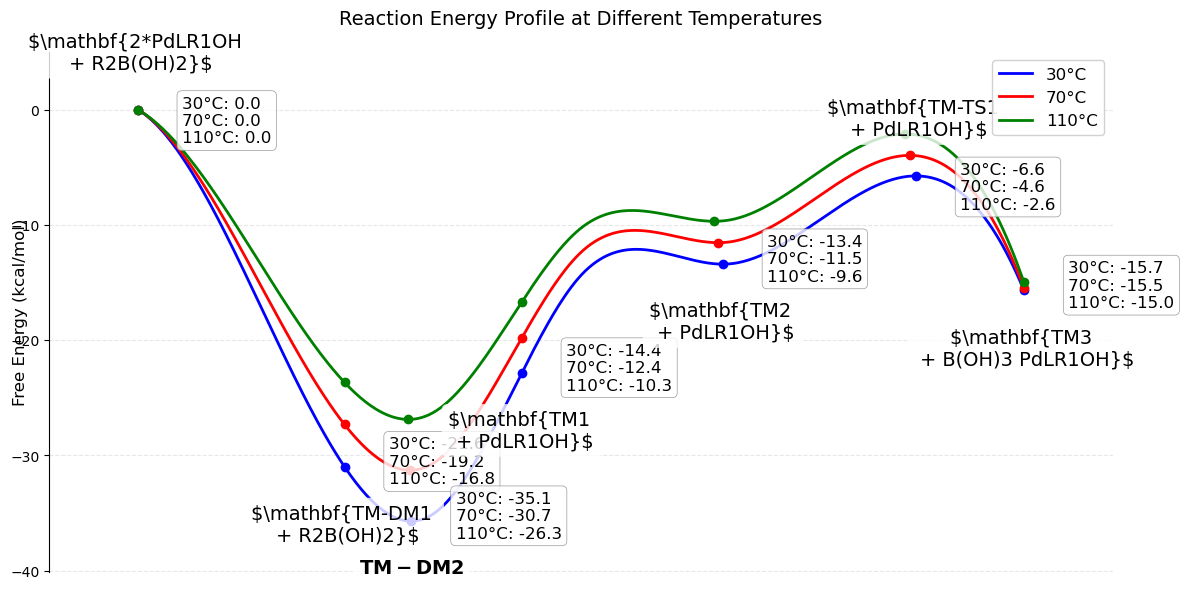

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize_scalar

# ──────────────────────────────────────────────
#  USER INPUT: define your intermediates here
#  with separate energies for each temperature
# ──────────────────────────────────────────────
# Temperature settings
TEMPERATURES = [30, 70, 110]  # °C
COLORS = ['blue', 'red', 'green']  # colors for each temperature

# Define points with energies for each temperature
# Format: {"label": "name", "energies": {30: value, 70: value, 110: value}}
points = [
    {"label": "2*PdLR1OH \n + R2B(OH)2", "energies": {30: 0.0, 70: 0.0, 110: 0.0}},  # Starting point
    {"label": "TM-DM1 \n + R2B(OH)2", "energies": {30: -21.6, 70: -19.2, 110: -16.8}},     
    {"label": "TM-DM2", "energies": {30: -35.1, 70: -30.7, 110: -26.3}}, 
    {"label": "TM1 \n + PdLR1OH", "energies": {30: -14.4, 70: -12.4, 110: -10.3}},   
    {"label": "TM2 \n + PdLR1OH", "energies": {30: -13.4, 70: -11.5, 110: -9.6}},   
    {"label": "TM-TS1 \n + PdLR1OH", "energies": {30: -6.6, 70: -4.6, 110: -2.6}},   
    {"label": "TM3 \n + B(OH)3 PdLR1OH", "energies": {30: -15.7, 70: -15.5, 110: -15.0}},    
]

# ──────────────────────────────────────────────
#  STYLE SETTINGS
# ──────────────────────────────────────────────
FIGURE_SIZE      = (12, 6)
CURVE_LINEWIDTH  = 2.0
POINT_SIZE       = 6
LABEL_FONTSIZE   = 14
ENERGY_FONTSIZE  = 13
LABEL_OFFSET_Y   = 2    # vertical offset for the label above/below the point
ENERGY_OFFSET_Y  = 1.2  # vertical offset for the kcal/mol number
X_PADDING        = 0.6  # extra horizontal space on left/right
Y_PADDING        = 5    # extra vertical space on top/bottom

def build_smooth_curve(x_pts, y_pts, n_interp=500):
    """
    Build a smooth cubic spline through the given control points.
    Returns (x_fine, y_fine) arrays for plotting.
    """
    cs = CubicSpline(x_pts, y_pts, bc_type="not-a-knot")
    x_fine = np.linspace(x_pts[0], x_pts[-1], n_interp)
    y_fine = cs(x_fine)
    return x_fine, y_fine

def label_position(idx, energy, all_energies):
    """
    Decide whether to place the label above or below the point.
    Transition states (local maxima) get labels above;
    intermediates (local minima) get labels below.
    """
    n = len(all_energies)
    is_max = (
        (idx == 0 and energy > all_energies[1]) or
        (idx == n - 1 and energy > all_energies[n - 2]) or
        (0 < idx < n - 1 and energy > all_energies[idx - 1] and energy > all_energies[idx + 1])
    )
    return is_max  # True → above, False → below

def plot_energy_profile(points, temperatures, colors):
    n = len(points)
    labels = [p["label"] for p in points]
    
    # Evenly spaced x positions
    x_pts = np.arange(n, dtype=float)
    
    # Get all energies to determine global y limits (for consistent scaling)
    all_energies = []
    for temp in temperatures:
        temp_energies = [p["energies"][temp] for p in points]
        all_energies.extend(temp_energies)
    global_y_min = min(all_energies)
    global_y_max = max(all_energies)
    
    # ── Figure setup ──────────────────────────────
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    
    # Store line objects for legend
    lines = []
    
    # Plot each temperature profile
    for temp_idx, (temp, color) in enumerate(zip(temperatures, colors)):
        # Get energies for this temperature
        energies = [p["energies"][temp] for p in points]
        
        # Build smooth curve for this temperature
        x_fine, y_fine = build_smooth_curve(x_pts, energies)
        
        # Draw curve with temperature-specific color
        line, = ax.plot(x_fine, y_fine, color=color, linewidth=CURVE_LINEWIDTH, 
                        zorder=2, label=f"{temp}°C")
        lines.append(line)
        
        # Draw points for this temperature
        for i, (label, energy) in enumerate(zip(labels, energies)):
            # Determine if this is a max or min using this temperature's energies
            above = label_position(i, energy, energies)
            
            # Find the true extremum of the spline near this point
            search_margin = 0.4
            x_lo = max(x_pts[0], i - search_margin)
            x_hi = min(x_pts[-1], i + search_margin)
            
            # Create cubic spline for this temperature
            cs_temp = CubicSpline(x_pts, energies)
            
            if above:
                result = minimize_scalar(lambda x: -cs_temp(x),
                                        bounds=(x_lo, x_hi), method="bounded")
            else:
                result = minimize_scalar(lambda x: cs_temp(x),
                                        bounds=(x_lo, x_hi), method="bounded")
            
            x_dot = result.x
            y_dot = cs_temp(x_dot)
            
            # Plot points with temperature color
            ax.plot(x_dot, y_dot, "o", color=color, markersize=POINT_SIZE, zorder=3)
    
    # Add labels and energy values (using one temperature as reference for positioning)
    # Using 30°C as reference for label positions
    reference_energies = [p["energies"][30] for p in points]
    reference_cs = CubicSpline(x_pts, reference_energies)
    
    for i, (label, point_data) in enumerate(zip(labels, points)):
        # Use 30°C to determine label placement
        ref_energy = reference_energies[i]
        above = label_position(i, ref_energy, reference_energies)
        
        # Find the extremum for label positioning using reference temperature
        search_margin = 0.4
        x_lo = max(x_pts[0], i - search_margin)
        x_hi = min(x_pts[-1], i + search_margin)
        
        if above:
            result = minimize_scalar(lambda x: -reference_cs(x),
                                    bounds=(x_lo, x_hi), method="bounded")
        else:
            result = minimize_scalar(lambda x: reference_cs(x),
                                    bounds=(x_lo, x_hi), method="bounded")
        
        x_dot = result.x
        y_dot = reference_cs(x_dot)
        
        sign = 1 if above else -1
        
        # Add chemical label
        ax.text(x_dot, y_dot + sign * (LABEL_OFFSET_Y + ENERGY_OFFSET_Y),
                f"$\\mathbf{{{label}}}$",
                ha="center", va="bottom" if above else "top",
                fontsize=LABEL_FONTSIZE, color="black",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.8))
        
        # Add energy values for all temperatures at this point
        energy_text = ""
        for temp in temperatures:
            energy_value = point_data["energies"][temp]
            energy_text += f"{temp}°C: {energy_value:.1f}\n"
        
        # Position for energy values (slightly offset from the label)
        y_offset = y_dot + sign * ENERGY_OFFSET_Y
        if not above:
            y_offset -= 0.5  # Shift down a bit for intermediates
        
        ax.text(x_dot + 0.3, y_offset,
                energy_text.rstrip(),
                ha="left", va="top" if above else "bottom",
                fontsize=ENERGY_FONTSIZE-1, color="black",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8, linewidth=0.5))

    # ── Axes styling ──────────────────────────────
    # Set limits
    ax.set_xlim(-X_PADDING, n - 1 + X_PADDING)
    ax.set_ylim(global_y_min - Y_PADDING, global_y_max + Y_PADDING)
    
    # Remove x-axis ticks (not meaningful)
    ax.set_xticks([])
    
    # Add legend
    ax.legend(loc='upper right', fontsize=12, framealpha=0.9)
    
    # Remove top/right spines for a clean look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    
    # Add y-axis label
    ax.set_ylabel("Free Energy (kcal/mol)", fontsize=12)
    ax.yaxis.set_label_coords(-0.02, 0.5)
    
    # Add a subtle grid
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Add title
    ax.set_title("Reaction Energy Profile at Different Temperatures", fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_energy_profile(points, TEMPERATURES, COLORS)

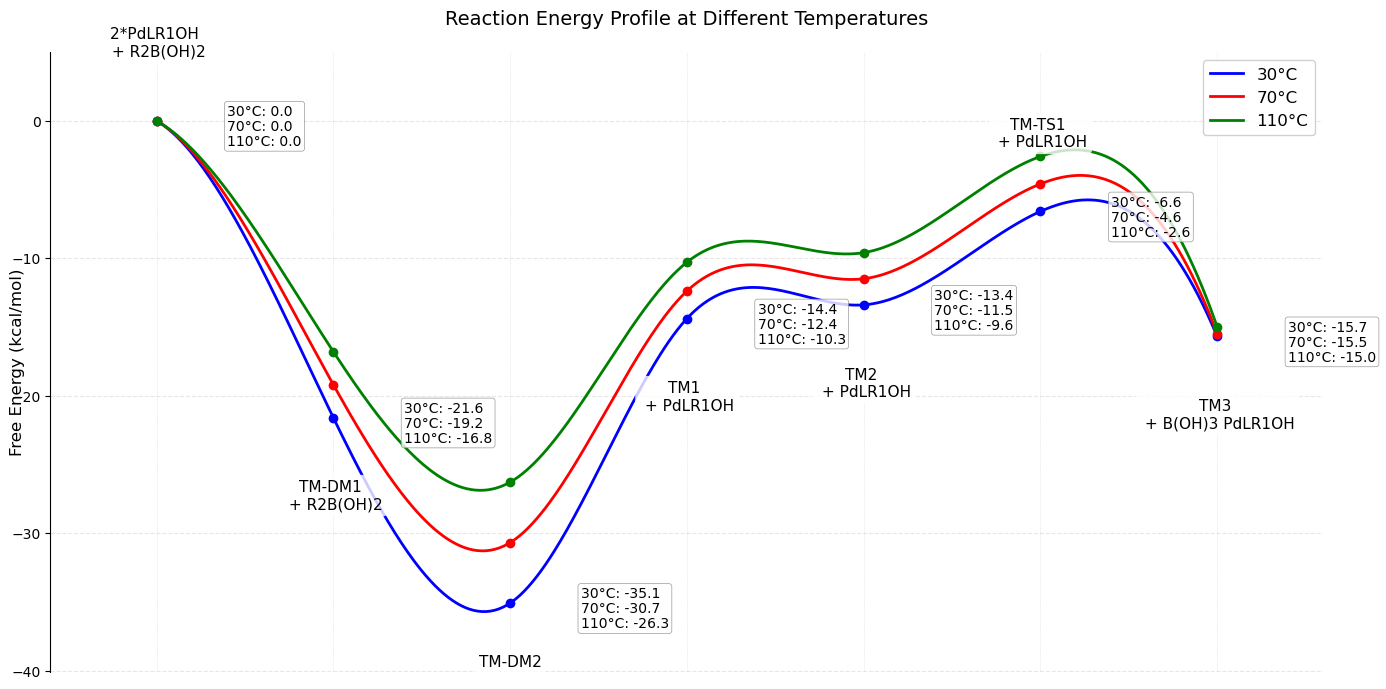

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# ──────────────────────────────────────────────
#  USER INPUT: define your intermediates here
#  with separate energies for each temperature
# ──────────────────────────────────────────────
# Temperature settings
TEMPERATURES = [30, 70, 110]  # °C
COLORS = ['blue', 'red', 'green']  # colors for each temperature

# Define points with energies for each temperature
points = [
    {"label": "2*PdLR1OH \n + R2B(OH)2", "energies": {30: 0.0, 70: 0.0, 110: 0.0}},  # Starting point
    {"label": "TM-DM1 \n + R2B(OH)2", "energies": {30: -21.6, 70: -19.2, 110: -16.8}},     
    {"label": "TM-DM2", "energies": {30: -35.1, 70: -30.7, 110: -26.3}}, 
    {"label": "TM1 \n + PdLR1OH", "energies": {30: -14.4, 70: -12.4, 110: -10.3}},   
    {"label": "TM2 \n + PdLR1OH", "energies": {30: -13.4, 70: -11.5, 110: -9.6}},   
    {"label": "TM-TS1 \n + PdLR1OH", "energies": {30: -6.6, 70: -4.6, 110: -2.6}},   
    {"label": "TM3 \n + B(OH)3 PdLR1OH", "energies": {30: -15.7, 70: -15.5, 110: -15.0}},    
]

# ──────────────────────────────────────────────
#  STYLE SETTINGS
# ──────────────────────────────────────────────
FIGURE_SIZE      = (14, 7)
CURVE_LINEWIDTH  = 2.0
POINT_SIZE       = 6
LABEL_FONTSIZE   = 11
ENERGY_FONTSIZE  = 10
LABEL_OFFSET_Y   = 2.5    # vertical offset for the label above/below the point
ENERGY_OFFSET_Y  = 1.2    # vertical offset for the kcal/mol number
X_PADDING        = 0.6    # extra horizontal space on left/right
Y_PADDING        = 5      # extra vertical space on top/bottom

def build_smooth_curve(x_pts, y_pts, n_interp=500):
    """
    Build a smooth cubic spline through the given control points.
    Returns (x_fine, y_fine) arrays for plotting.
    """
    cs = CubicSpline(x_pts, y_pts, bc_type="not-a-knot")
    x_fine = np.linspace(x_pts[0], x_pts[-1], n_interp)
    y_fine = cs(x_fine)
    return x_fine, y_fine

def label_position(idx, energy, all_energies):
    """
    Decide whether to place the label above or below the point.
    Transition states (local maxima) get labels above;
    intermediates (local minima) get labels below.
    """
    n = len(all_energies)
    is_max = (
        (idx == 0 and energy > all_energies[1]) or
        (idx == n - 1 and energy > all_energies[n - 2]) or
        (0 < idx < n - 1 and energy > all_energies[idx - 1] and energy > all_energies[idx + 1])
    )
    return is_max  # True → above, False → below

def plot_energy_profile(points, temperatures, colors):
    n = len(points)
    labels = [p["label"] for p in points]
    
    # Evenly spaced x positions - EQUAL SPACING
    x_pts = np.arange(n, dtype=float)
    
    # Get all energies to determine global y limits (for consistent scaling)
    all_energies = []
    for temp in temperatures:
        temp_energies = [p["energies"][temp] for p in points]
        all_energies.extend(temp_energies)
    global_y_min = min(all_energies)
    global_y_max = max(all_energies)
    
    # ── Figure setup ──────────────────────────────
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    
    # Plot each temperature profile
    for temp, color in zip(temperatures, colors):
        # Get energies for this temperature
        energies = [p["energies"][temp] for p in points]
        
        # Build smooth curve for this temperature
        x_fine, y_fine = build_smooth_curve(x_pts, energies)
        
        # Draw curve with temperature-specific color
        ax.plot(x_fine, y_fine, color=color, linewidth=CURVE_LINEWIDTH, 
                zorder=2, label=f"{temp}°C")
        
        # Draw points at EXACTLY the evenly spaced x-positions (not shifted)
        for i, energy in enumerate(energies):
            ax.plot(x_pts[i], energy, "o", color=color, markersize=POINT_SIZE, zorder=3)
    
    # Add labels and energy values at the exact x-positions
    for i, (label, point_data) in enumerate(zip(labels, points)):
        # Use 30°C to determine label placement (above or below)
        ref_energy = point_data["energies"][30]
        above = label_position(i, ref_energy, [p["energies"][30] for p in points])
        
        # Use the exact x-position (evenly spaced)
        x_pos = x_pts[i]
        y_pos = ref_energy
        
        sign = 1 if above else -1
        
        # Add chemical label (normal text, no math bold)
        lines_in_label = label.count('\n') + 1
        label_offset = LABEL_OFFSET_Y + (lines_in_label - 1) * 0.8
        
        ax.text(x_pos, y_pos + sign * (label_offset + ENERGY_OFFSET_Y),
                label,
                ha="center", va="bottom" if above else "top",
                fontsize=LABEL_FONTSIZE, color="black",
                linespacing=1.2,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.8))
        
        # Add energy values for all temperatures at this point
        energy_text = ""
        for temp in temperatures:
            energy_value = point_data["energies"][temp]
            energy_text += f"{temp}°C: {energy_value:.1f}\n"
        
        # Position for energy values
        y_offset = y_pos + sign * ENERGY_OFFSET_Y
        if not above:
            y_offset -= 0.8  # Shift down a bit for intermediates
        
        ax.text(x_pos + 0.4, y_offset,
                energy_text.rstrip(),
                ha="left", va="top" if above else "bottom",
                fontsize=ENERGY_FONTSIZE, color="black",
                linespacing=1.1,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="gray", alpha=0.8, linewidth=0.5))

    # ── Axes styling ──────────────────────────────
    # Set limits - equal spacing is ensured by x_pts being evenly spaced
    ax.set_xlim(-X_PADDING, n - 1 + X_PADDING)
    ax.set_ylim(global_y_min - Y_PADDING, global_y_max + Y_PADDING)
    
    # Add vertical lines at each point position to show equal spacing
    for i in range(n):
        ax.axvline(x=i, color='gray', linestyle=':', alpha=0.3, linewidth=0.5)
    
    # Remove x-axis ticks (not meaningful)
    ax.set_xticks([])
    
    # Add legend
    ax.legend(loc='upper right', fontsize=12, framealpha=0.9)
    
    # Remove top/right spines for a clean look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    
    # Add y-axis label
    ax.set_ylabel("Free Energy (kcal/mol)", fontsize=12)
    ax.yaxis.set_label_coords(-0.02, 0.5)
    
    # Add a subtle grid
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Add title
    ax.set_title("Reaction Energy Profile at Different Temperatures", fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_energy_profile(points, TEMPERATURES, COLORS)

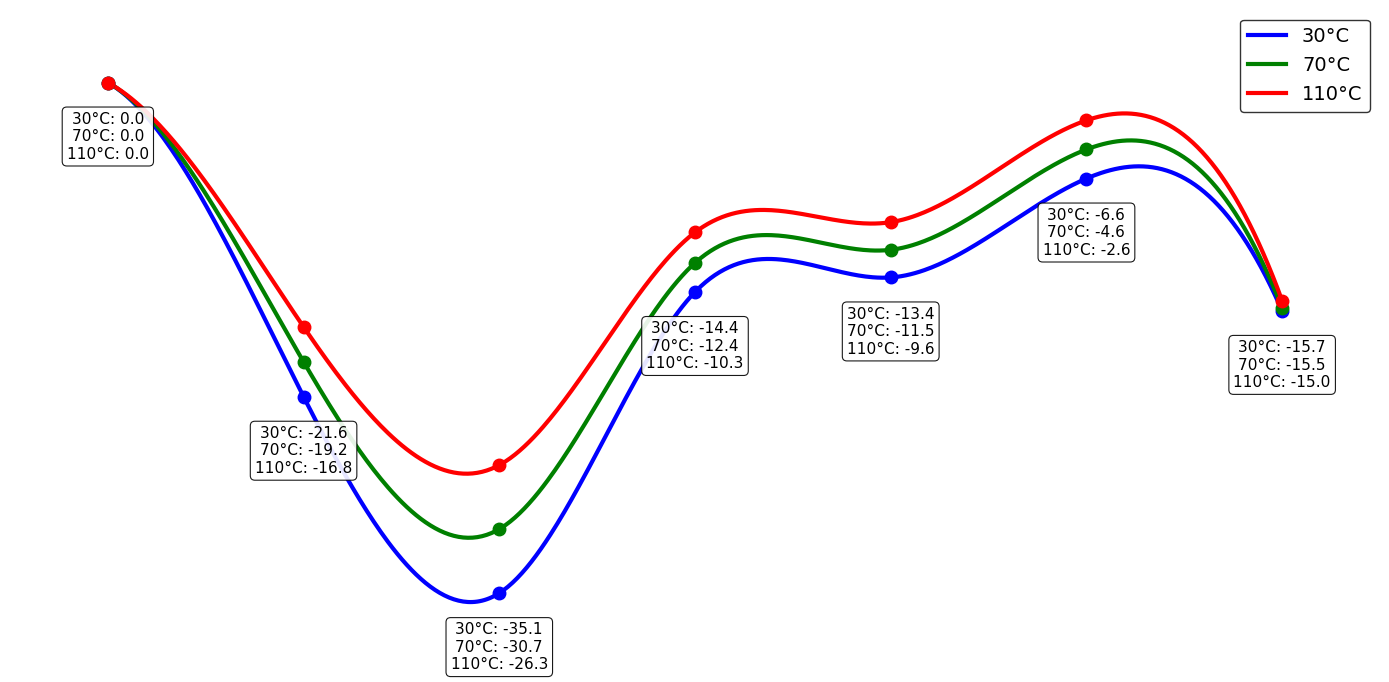

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# ──────────────────────────────────────────────
#  USER INPUT: define your intermediates here
#  with separate energies for each temperature
# ──────────────────────────────────────────────
# Temperature settings
TEMPERATURES = [30, 70, 110]  # °C
COLORS = ['blue', 'green', 'red']  # colors for each temperature

# Define points with energies for each temperature
points = [
    {"label": "", "energies": {30: 0.0, 70: 0.0, 110: 0.0}},  # Starting point
    {"label": "", "energies": {30: -21.6, 70: -19.2, 110: -16.8}},     
    {"label": "", "energies": {30: -35.1, 70: -30.7, 110: -26.3}}, 
    {"label": "", "energies": {30: -14.4, 70: -12.4, 110: -10.3}},   
    {"label": "", "energies": {30: -13.4, 70: -11.5, 110: -9.6}},   
    {"label": "", "energies": {30: -6.6, 70: -4.6, 110: -2.6}},   
    {"label": "", "energies": {30: -15.7, 70: -15.5, 110: -15.0}},    
]

# ──────────────────────────────────────────────
#  STYLE SETTINGS
# ──────────────────────────────────────────────
FIGURE_SIZE      = (14, 7)
CURVE_LINEWIDTH  = 3.0
POINT_SIZE       = 9
ENERGY_FONTSIZE  = 11
Y_PADDING        = 5      # extra vertical space on top/bottom
BOX_OFFSET_Y     = 2    # vertical offset for energy box below the lowest point

def build_smooth_curve(x_pts, y_pts, n_interp=500):
    """
    Build a smooth cubic spline through the given control points.
    Returns (x_fine, y_fine) arrays for plotting.
    """
    cs = CubicSpline(x_pts, y_pts, bc_type="not-a-knot")
    x_fine = np.linspace(x_pts[0], x_pts[-1], n_interp)
    y_fine = cs(x_fine)
    return x_fine, y_fine

def plot_energy_profile(points, temperatures, colors):
    n = len(points)
    
    # Evenly spaced x positions
    x_pts = np.arange(n, dtype=float)
    
    # Get all energies to determine global y limits
    all_energies = []
    for temp in temperatures:
        temp_energies = [p["energies"][temp] for p in points]
        all_energies.extend(temp_energies)
    global_y_min = min(all_energies)
    global_y_max = max(all_energies)
    
    # Find the lowest energy at each x-position (across all temperatures)
    lowest_energies = []
    for i in range(n):
        energies_at_point = [points[i]["energies"][temp] for temp in temperatures]
        lowest_energies.append(min(energies_at_point))
    
    # ── Figure setup ──────────────────────────────
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    
    # Plot each temperature profile
    for temp, color in zip(temperatures, colors):
        # Get energies for this temperature
        energies = [p["energies"][temp] for p in points]
        
        # Build smooth curve for this temperature
        x_fine, y_fine = build_smooth_curve(x_pts, energies)
        
        # Draw curve with temperature-specific color
        ax.plot(x_fine, y_fine, color=color, linewidth=CURVE_LINEWIDTH, 
                zorder=2, label=f"{temp}°C")
        
        # Draw points at exactly the evenly spaced x-positions
        for i, energy in enumerate(energies):
            ax.plot(x_pts[i], energy, "o", color=color, markersize=POINT_SIZE, zorder=3)
    
    # Add energy value boxes right beneath the lowest point at each x-position
    for i in range(n):
        x_pos = x_pts[i]
        
        # Get all energy values at this point
        energy_values = []
        for temp in temperatures:
            energy_value = points[i]["energies"][temp]
            energy_values.append((temp, energy_value))
        
        # Sort by temperature for consistent display
        energy_values.sort(key=lambda x: x[0])
        
        # Create the energy text
        energy_text = "\n".join([f"{temp}°C: {value:.1f}" for temp, value in energy_values])
        
        # Position the box right beneath the lowest point
        lowest_y = lowest_energies[i]
        box_y = lowest_y - BOX_OFFSET_Y
        
        # Add text box
        ax.text(x_pos, box_y,
                energy_text,
                ha="center", va="top",
                fontsize=ENERGY_FONTSIZE, color="black",
                linespacing=1.2,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", 
                         edgecolor="black", alpha=0.9, linewidth=0.8))

    # ── Axes styling ──────────────────────────────
    # Set limits
    ax.set_xlim(-0.5, n - 1 + 0.5)
    ax.set_ylim(global_y_min - Y_PADDING, global_y_max + Y_PADDING)
    
    # Add vertical dotted lines at each point position for reference
    # for i in range(n):
    #     ax.axvline(x=i, color='gray', linestyle=':', alpha=0.3, linewidth=0.5)
    
    # Remove x-axis ticks
    ax.set_xticks([])
    
    # Add legend
    ax.legend(loc='upper right', fontsize=14, framealpha=0.8, edgecolor='black')

    # Hide y-axis ticks and labels
    ax.set_yticklabels([])  # Remove y-axis tick labels
    ax.tick_params(axis='y', which='both', left=False)  # Remove y-axis ticks
    
    # Remove top/right spines for a clean look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    
    # Add y-axis label
    # ax.set_ylabel("Free Energy (kcal/mol)", fontsize=12)
    # ax.yaxis.set_label_coords(-0.02, 0.5)
    
    # Add a subtle grid
    # ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Add title
    # ax.set_title("Reaction Energy Profile at Different Temperatures", fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_energy_profile(points, TEMPERATURES, COLORS)